In [1]:
#1
import os
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] += ";C:\\hadoop\\bin"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Classification") \
    .config("spark.jars.packages", 
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://localhost:9000") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

In [2]:
#2
df = spark.read.csv(
    "data/processed/hasil_no_outlier.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536373|    21730|glass star froste...|       6|2010-12-01 09:02:00|     4.25|   17850.0|United Kingdom|
|   536390|   85099B|jumbo bag red ret...|     100|2010-12-01 10:19:00|     1.65|   17511.0|United Kingdom|
|   536398|    21980|pack of 12 red re...|      24|2010-12-01 10:52:00|     0.29|   13448.0|United Kingdom|
|   536407|    22632|hand warmer red p...|       6|2010-12-01 11:34:00|     1.85|   17850.0|United Kingdom|
|   536408|    22553|plasters in tin s...|      12|2010-12-01 11:41:00|     1.65|   14307.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows


In [3]:
#3
from pyspark.sql.functions import max

max_date = df.select(max("InvoiceDate")).collect()[0][0]
print(max_date)

2011-12-09 12:50:00


In [4]:
#4
from datetime import timedelta

reference_date = max_date + timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [5]:
#5
from pyspark.sql.functions import col, sum, count, max, datediff, lit, to_timestamp

df = df.withColumn("InvoiceDate", to_timestamp(col("InvoiceDate")))
df = df.withColumn("TotalPrice", col("Quantity") * col("UnitPrice"))

df_rfm = df.groupBy("CustomerID").agg(
    datediff(lit(reference_date), max("InvoiceDate")).alias("Recency"),
    count("InvoiceNo").alias("Frequency"),
    sum("TotalPrice").alias("Monetary")
)

df_rfm.show(5)

+----------+-------+---------+------------------+
|CustomerID|Recency|Frequency|          Monetary|
+----------+-------+---------+------------------+
|   16916.0|     24|      134|            548.73|
|   17884.0|      4|      111|            685.47|
|   13956.0|      6|      146|            989.32|
|   13094.0|     22|       22|           1622.04|
|   12493.0|    166|       19|362.78999999999996|
+----------+-------+---------+------------------+
only showing top 5 rows


In [6]:
#6
# Label:
# 1 = customer masih aktif (<= 90 hari)
# 0 = customer tidak aktif (> 90 hari)
from pyspark.sql.functions import when, col

df_ml = df_rfm.withColumn(
    "RepeatPurchase",
    when(col("Recency") <= 90, 1).otherwise(0)
)

df_ml.groupBy("RepeatPurchase").count().show()

+--------------+-----+
|RepeatPurchase|count|
+--------------+-----+
|             1| 2859|
|             0| 1431|
+--------------+-----+



In [7]:
#7
df_rfm.select("Recency").describe().show()
df_rfm.select("Frequency").describe().show()
df_rfm.select("Monetary").describe().show()

+-------+------------------+
|summary|           Recency|
+-------+------------------+
|  count|              4290|
|   mean| 93.12913752913752|
| stddev|100.00563338971439|
|    min|                 1|
|    max|               374|
+-------+------------------+

+-------+-----------------+
|summary|        Frequency|
+-------+-----------------+
|  count|             4290|
|   mean|89.10955710955712|
| stddev|220.1616611299815|
|    min|                1|
|    max|             7584|
+-------+-----------------+

+-------+------------------+
|summary|          Monetary|
+-------+------------------+
|  count|              4290|
|   mean|1604.4927296037326|
| stddev|4808.6335406392045|
|    min|               2.9|
|    max|         158949.56|
+-------+------------------+



In [8]:
#8
quantiles_monetary = df_rfm.approxQuantile("Monetary", [0.95], 0)
quantiles_frequency = df_rfm.approxQuantile("Frequency", [0.95], 0)

cap_monetary = quantiles_monetary[0]
cap_frequency = quantiles_frequency[0]

print("Cap Monetary:", cap_monetary)
print("Cap Frequency:", cap_frequency)

Cap Monetary: 5227.479999999999
Cap Frequency: 304.0


In [9]:
#9
from pyspark.sql.functions import when, col

df_rfm = df_rfm.withColumn(
    "Monetary_capped",
    when(col("Monetary") > cap_monetary, cap_monetary).otherwise(col("Monetary"))
)

df_rfm = df_rfm.withColumn(
    "Frequency_capped",
    when(col("Frequency") > cap_frequency, cap_frequency).otherwise(col("Frequency"))
)

df_rfm.show(5)

+----------+-------+---------+------------------+------------------+----------------+
|CustomerID|Recency|Frequency|          Monetary|   Monetary_capped|Frequency_capped|
+----------+-------+---------+------------------+------------------+----------------+
|   16916.0|     24|      134|            548.73|            548.73|           134.0|
|   17884.0|      4|      111|            685.47|            685.47|           111.0|
|   13956.0|      6|      146|            989.32|            989.32|           146.0|
|   13094.0|     22|       22|           1622.04|           1622.04|            22.0|
|   12493.0|    166|       19|362.78999999999996|362.78999999999996|            19.0|
+----------+-------+---------+------------------+------------------+----------------+
only showing top 5 rows


In [10]:
#10
from pyspark.sql.functions import log1p

df_rfm = df_rfm.withColumn("Monetary_log", log1p(col("Monetary_capped")))
df_rfm = df_rfm.withColumn("Frequency_log", log1p(col("Frequency_capped")))
df_rfm = df_rfm.dropna(subset=["Recency", "Frequency_log", "Monetary_log"])

df_rfm.show(5)

+----------+-------+---------+------------------+------------------+----------------+-----------------+------------------+
|CustomerID|Recency|Frequency|          Monetary|   Monetary_capped|Frequency_capped|     Monetary_log|     Frequency_log|
+----------+-------+---------+------------------+------------------+----------------+-----------------+------------------+
|   16916.0|     24|      134|            548.73|            548.73|           134.0| 6.30942724860029|  4.90527477843843|
|   17884.0|      4|      111|            685.47|            685.47|           111.0| 6.53156252432599| 4.718498871295094|
|   13956.0|      6|      146|            989.32|            989.32|           146.0|6.898028123223555| 4.990432586778736|
|   13094.0|     22|       22|           1622.04|           1622.04|            22.0|7.392056212928697|3.1354942159291497|
|   12493.0|    166|       19|362.78999999999996|362.78999999999996|            19.0|5.896576778075664| 2.995732273553991|
+----------+----

In [11]:
#11
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import log1p, when

# Tambah fitur AvgTransaction
df_ml = df_ml.withColumn("AvgTransaction", col("Monetary") / col("Frequency"))
df_ml = df_ml.withColumn("Monetary_log", log1p(col("Monetary"))) \
             .withColumn("Frequency_log", log1p(col("Frequency")))

# Class weight untuk handle imbalanced (1=2859, 0=1431)
ratio = 2859 / 1431
df_ml = df_ml.withColumn(
    "weight",
    when(col("RepeatPurchase") == 0, ratio).otherwise(1.0)
)

# Recency TIDAK dipakai (label dari Recency → hindari leakage)
assembler = VectorAssembler(
    inputCols=["Frequency_log", "Monetary_log", "AvgTransaction"],
    outputCol="features"
)
df_vector = assembler.transform(df_ml)

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(df_vector)
df_final = scaler_model.transform(df_vector)

In [12]:
#12
from pyspark.ml.classification import LogisticRegression

train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(
    labelCol="RepeatPurchase",
    featuresCol="scaledFeatures",
    weightCol="weight",  # ← tambahan ini
    maxIter=100
)

lr_model = lr.fit(train_data)
predictions = lr_model.transform(test_data)
predictions.select("CustomerID", "RepeatPurchase", "probability", "prediction").show(10)

+----------+--------------+--------------------+----------+
|CustomerID|RepeatPurchase|         probability|prediction|
+----------+--------------+--------------------+----------+
|   12349.0|             1|[0.31392783851817...|       1.0|
|   12354.0|             0|[0.36878977574034...|       1.0|
|   12356.0|             1|[0.2691648793173,...|       1.0|
|   12361.0|             0|[0.75504079979778...|       0.0|
|   12370.0|             1|[0.16711313215470...|       1.0|
|   12374.0|             1|[0.49864875464603...|       1.0|
|   12381.0|             1|[0.28683423911857...|       1.0|
|   12391.0|             1|[0.41345293244364...|       1.0|
|   12405.0|             0|[0.33887005426014...|       1.0|
|   12406.0|             1|[0.19431037243209...|       1.0|
+----------+--------------+--------------------+----------+
only showing top 10 rows


In [13]:
#13
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
   labelCol="RepeatPurchase",
   predictionCol="prediction"
)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print("=== HASIL EVALUASI ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


=== HASIL EVALUASI ===
Accuracy  : 0.7021
Precision : 0.7234
Recall    : 0.7021
F1-Score  : 0.7086


In [14]:
from sklearn.metrics import classification_report

y_true = predictions.select("RepeatPurchase").toPandas()
y_pred = predictions.select("prediction").toPandas()

print(classification_report(
    y_true, 
    y_pred, 
    target_names=["Tidak Aktif (0)", "Aktif (1)"]
))

                 precision    recall  f1-score   support

Tidak Aktif (0)       0.54      0.67      0.60       268
      Aktif (1)       0.81      0.72      0.76       541

       accuracy                           0.70       809
      macro avg       0.68      0.69      0.68       809
   weighted avg       0.72      0.70      0.71       809



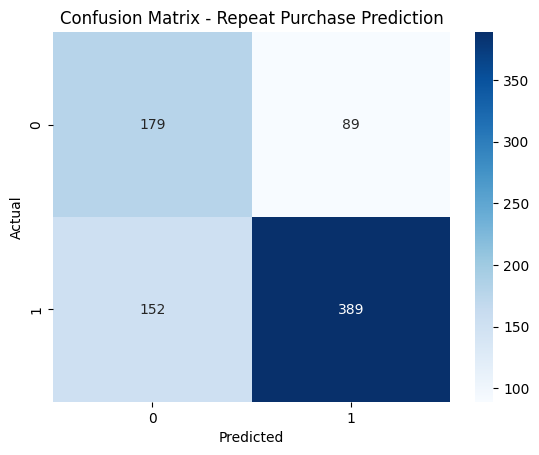

In [15]:
#14
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ambil data label asli dan prediksi ke pandas
y_true = predictions.select("RepeatPurchase").toPandas()
y_pred = predictions.select("prediction").toPandas()

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Repeat Purchase Prediction')
plt.show()

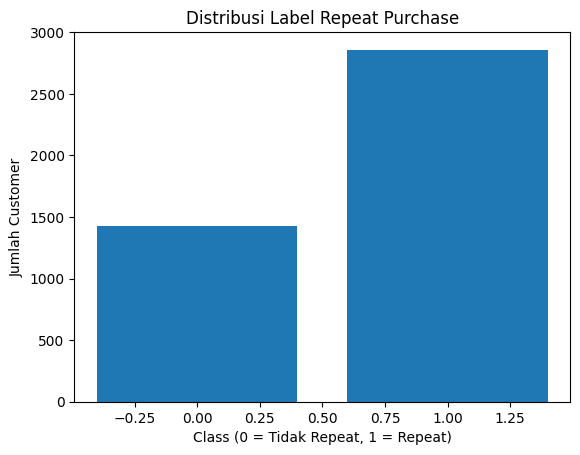

In [16]:
#15
import matplotlib.pyplot as plt

# Convert ke pandas
label_dist = df_ml.groupBy("RepeatPurchase").count().toPandas()

plt.figure()
plt.bar(label_dist["RepeatPurchase"], label_dist["count"])
plt.xlabel("Class (0 = Tidak Repeat, 1 = Repeat)")
plt.ylabel("Jumlah Customer")
plt.title("Distribusi Label Repeat Purchase")
plt.show()



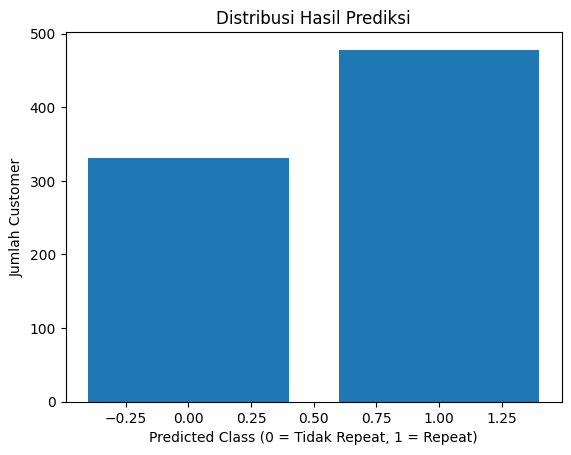

In [17]:
#16
# Distribusi hasil prediksi
pred_dist = predictions.groupBy("prediction").count().toPandas()

plt.figure()
plt.bar(pred_dist["prediction"], pred_dist["count"])
plt.xlabel("Predicted Class (0 = Tidak Repeat, 1 = Repeat)")
plt.ylabel("Jumlah Customer")
plt.title("Distribusi Hasil Prediksi")
plt.show()


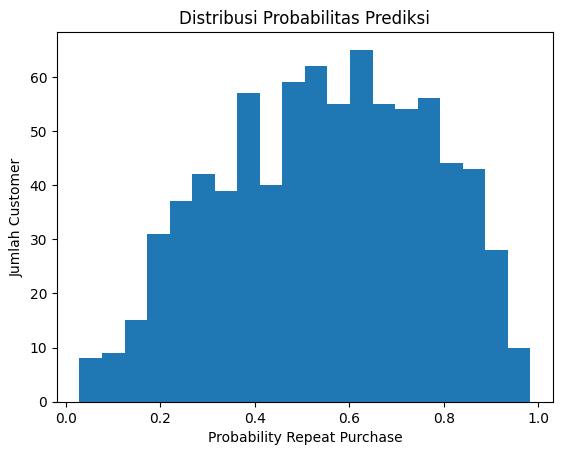

In [18]:
#17
# Ambil probability class 1
prob_df = predictions.select("probability").toPandas()

# Extract nilai probability class 1
prob_df["prob_1"] = prob_df["probability"].apply(lambda x: float(x[1]))

plt.figure()
plt.hist(prob_df["prob_1"], bins=20)
plt.xlabel("Probability Repeat Purchase")
plt.ylabel("Jumlah Customer")
plt.title("Distribusi Probabilitas Prediksi")
plt.show()


In [19]:
#18
from pyspark.ml.classification import DecisionTreeClassifier

# Inisialisasi model Decision Tree
dt = DecisionTreeClassifier(
    labelCol="RepeatPurchase", 
    featuresCol="scaledFeatures",
    seed=42
)

# Training model
dt_model = dt.fit(train_data)

# Prediksi menggunakan Decision Tree
dt_predictions = dt_model.transform(test_data)

# Evaluasi Decision Tree
dt_accuracy = evaluator.evaluate(dt_predictions, {evaluator.metricName: "accuracy"})
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.7206


In [20]:
#19
# Ubah hasil prediksi ke Pandas (hanya ambil kolom yang perlu)
final_results_pd = predictions.select("CustomerID", "RepeatPurchase", "prediction", "probability").toPandas()

# Simpan menggunakan Pandas (tidak akan error UnsatisfiedLinkError)
local_csv_path = "data/gold/final_classification_results.csv"
final_results_pd.to_csv(local_csv_path, index=False)

print(f"Data berhasil disimpan menggunakan Pandas di: {local_csv_path}")

Data berhasil disimpan menggunakan Pandas di: data/gold/final_classification_results.csv
